<a href="https://colab.research.google.com/github/romenmeitei/SMA/blob/main/Robust_docking_analysis_Blind_docking_%26_Site_focused.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pocket residues: 75–115
Pocket atom count: 408
Pocket centroid: [ 2.09821324 -1.8983848  -2.41302451]

Raw results:


,ligand,condition,mode_id,vina_score,pose_x,pose_y,pose_z,min_distance_to_pocket,centroid_distance_to_pocket,near_pocket
0,Amentoflavone,focused,1,-8.6,1.583504,-11.836898,-2.754229,1.934322,9.957680,True
1,Amentoflavone,focused,2,-8.4,1.262715,-12.690480,-1.014016,2.713466,10.914421,True
2,Amentoflavone,focused,3,-8.2,3.103196,-11.979272,-1.443200,2.620706,10.177173,True
3,Amentoflavone,focused,4,-8.0,3.136573,-11.519131,-1.433512,1.964377,9.726068,True
4,Amentoflavone,focused,5,-7.7,-4.286671,10.494941,4.372885,5.269000,15.505155,False
5,Amentoflavone,focused,6,-7.6,0.726776,-11.936779,-5.697215,2.681126,10.650638,True
6,Amentoflavone,focused,7,-7.5,2.272402,-12.710246,-3.176987,3.118096,10.840218,True
7,Amentoflavone,focused,8,-7.4,0.891033,-12.312186,-1.958544,2.493804,10.493384,True
8,Amentoflavone,focused,9,-7.2,-10.983155,6.127347,-9.252217,3.519320,16.802057,True
9,Amentoflavone,large,1,-8.5,2.195569,-11.977923,-1.977373,2.025842,10.089418,True



Summary:


,ligand,condition,n_poses,mean_min_distance,sd_min_distance,median_min_distance,mean_centroid_distance,sd_centroid_distance,mean_vina_score,sd_vina_score,pct_near_pocket
0,Amentoflavone,focused,9,2.923802,1.010681,2.681126,11.674088,2.590094,-7.844444,0.479873,88.888889
1,Amentoflavone,large,9,3.405225,1.606055,2.720974,13.090311,2.974817,-7.877778,0.243812,77.777778
2,Ginkgetin,focused,9,2.176532,0.471370,2.182622,11.915526,2.613749,-7.055556,0.450309,100.000000
3,Ginkgetin,large,9,3.380533,0.935049,2.949277,15.223420,0.656204,-8.300000,0.380789,88.888889
4,Withanolide D,focused,9,1.855534,0.418159,1.838581,10.699992,1.657309,-7.588889,0.470225,100.000000
5,Withanolide D,large,9,3.077666,0.697573,2.982464,15.360188,0.835466,-8.422222,0.286259,100.000000


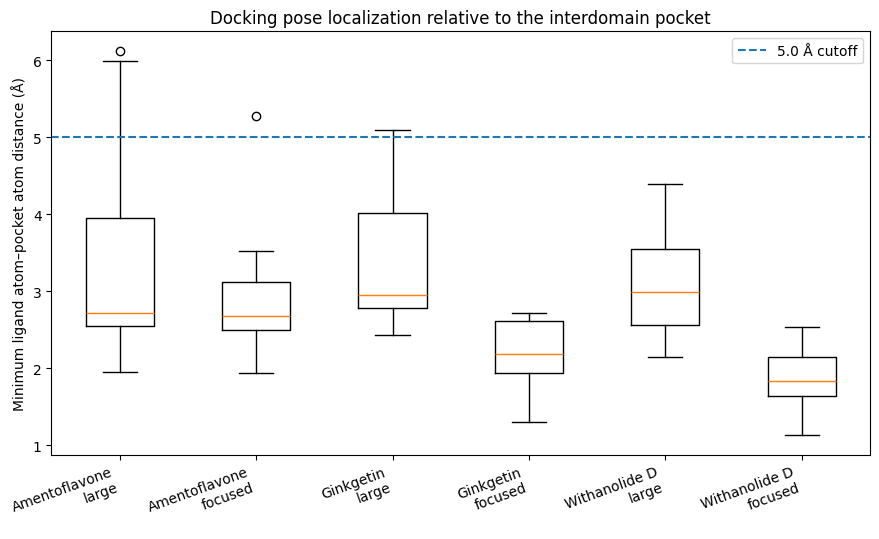

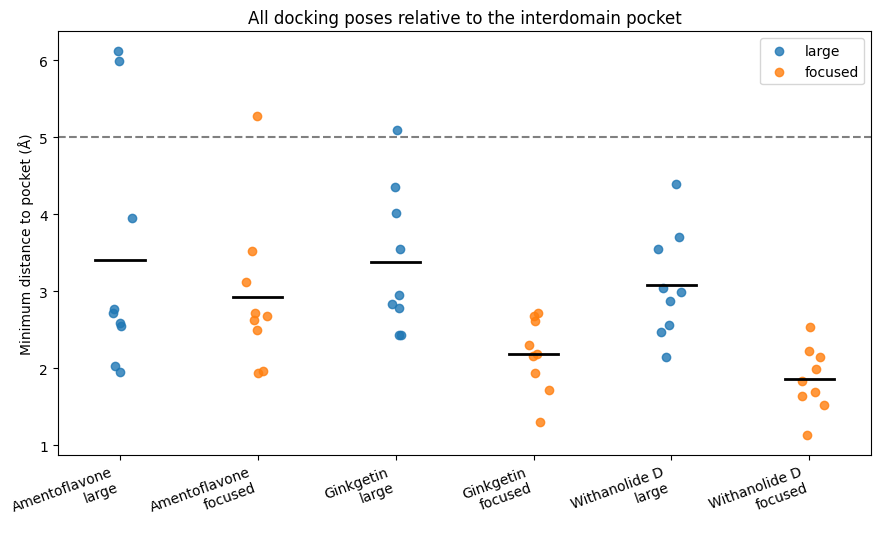

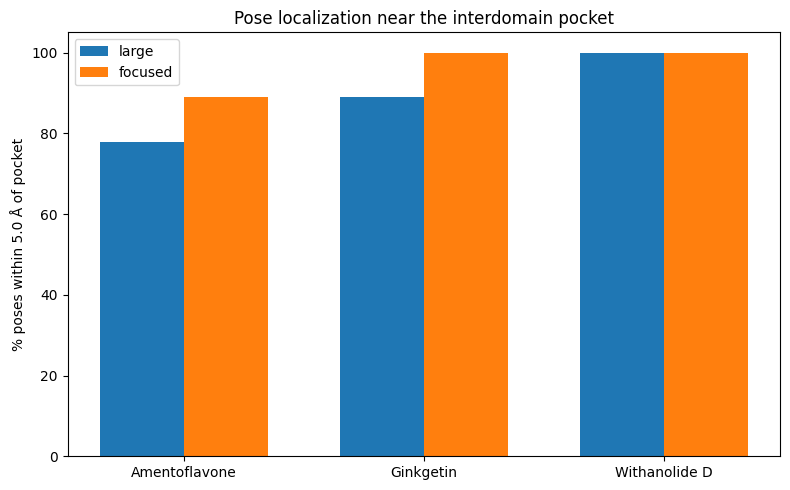


Percent near pocket:


,ligand,condition,near_pocket,percent
0,Amentoflavone,focused,0.888889,88.888889
1,Amentoflavone,large,0.777778,77.777778
2,Ginkgetin,focused,1.000000,100.000000
3,Ginkgetin,large,0.888889,88.888889
4,Withanolide D,focused,1.000000,100.000000
5,Withanolide D,large,1.000000,100.000000



Statistics:


,ligand,n_large,n_focused,mean_large,mean_focused,median_large,median_focused,mannwhitney_u,p_mannwhitney,welch_t,p_welch
0,Amentoflavone,9,9,3.405225,2.923802,2.720974,2.681126,47.0,0.596242,0.761103,0.459706
1,Ginkgetin,9,9,3.380533,2.176532,2.949277,2.182622,75.0,0.002680,3.449393,0.004912
2,Withanolide D,9,9,3.077666,1.855534,2.982464,1.838581,78.0,0.001086,4.508023,0.000579



Best poses only:


,ligand,condition,mode_id,vina_score,pose_x,pose_y,pose_z,min_distance_to_pocket,centroid_distance_to_pocket,near_pocket
0,Amentoflavone,focused,1,-8.6,1.583504,-11.836898,-2.754229,1.934322,9.957680,True
9,Amentoflavone,large,1,-8.5,2.195569,-11.977923,-1.977373,2.025842,10.089418,True
18,Ginkgetin,focused,1,-7.7,2.971159,-11.791310,-3.125129,2.182622,9.956862,True
27,Ginkgetin,large,1,-9.2,-2.581667,10.040387,3.375652,2.424514,14.069269,True
36,Withanolide D,focused,1,-8.5,2.040493,-11.528946,-0.839580,1.985707,9.758420,True
45,Withanolide D,large,1,-9.1,-2.627098,10.156891,3.213513,2.982464,14.117937,True


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

# =========================================================
# USER INPUT SECTION
# =========================================================

receptor_file = "/content/2lyv_prepared.pdbqt"

ligand_files = {
    "Amentoflavone": {
        "focused": "/content/161671_uff_e=24798.81_uff_e=15712.38_out.pdbqt",
        "large":   "/content/161671_large_out.pdbqt",
    },
    "Ginkgetin": {
        "focused": "/content/5271805_uff_e=884.44_uff_e=811.43_out.pdbqt",
        "large":   "/content/5271805_large_out.pdbqt",
    },
    "Withanolide D": {
        "focused": "/content/5281600_uff_e=855.30_uff_e=760.87_out.pdbqt",
        "large":   "/content/5281600_large_out.pdbqt",
    }
}

# Expanded interdomain region on 2LYV chain A
chain_id = "A"
pocket_residues = list(range(75, 116))   # 75–115 inclusive

# Cutoff for defining "near pocket"
distance_cutoff = 5.0   # Å
# You can also test 6.0 or 8.0 Å as sensitivity checks

# =========================================================
# PDBQT PARSER FUNCTIONS
# =========================================================

def parse_pdbqt_atom_line(line):
    rec = line[0:6].strip()
    if rec not in ("ATOM", "HETATM"):
        return None

    atom_name = line[12:16].strip()
    res_name  = line[17:20].strip()
    chain     = line[21].strip() if len(line) > 21 else ""
    res_seq_s = line[22:26].strip()

    try:
        res_seq = int(res_seq_s)
    except:
        res_seq = None

    try:
        x = float(line[30:38].strip())
        y = float(line[38:46].strip())
        z = float(line[46:54].strip())
    except:
        return None

    element_guess = re.sub(r'[^A-Za-z]', '', atom_name)
    if len(element_guess) == 0:
        element = "C"
    else:
        element_guess = element_guess.capitalize()
        if element_guess[:2] in {"Cl", "Br", "Na", "Mg", "Ca", "Zn", "Fe", "Mn"}:
            element = element_guess[:2]
        else:
            element = element_guess[0]

    return {
        "record": rec,
        "atom_name": atom_name,
        "res_name": res_name,
        "chain": chain,
        "res_seq": res_seq,
        "x": x, "y": y, "z": z,
        "element": element
    }

ATOMIC_MASSES = {
    "H": 1.008, "C": 12.011, "N": 14.007, "O": 15.999, "P": 30.974, "S": 32.06,
    "F": 18.998, "Cl": 35.45, "Br": 79.904, "I": 126.90,
    "Na": 22.990, "Mg": 24.305, "Ca": 40.078, "Zn": 65.38, "Fe": 55.845, "Mn": 54.938
}

def atom_mass(element):
    return ATOMIC_MASSES.get(element, 12.011)

def center_of_mass(atom_list):
    masses = np.array([atom_mass(a["element"]) for a in atom_list], dtype=float)
    coords = np.array([[a["x"], a["y"], a["z"]] for a in atom_list], dtype=float)
    return (coords * masses[:, None]).sum(axis=0) / masses.sum()

def centroid(coords):
    arr = np.array(coords, dtype=float)
    return arr.mean(axis=0)

def euclidean(a, b):
    return float(np.linalg.norm(np.array(a) - np.array(b)))

def parse_receptor_region_atoms(pdbqt_path, chain_id="A", residues=None):
    if residues is None:
        raise ValueError("residues must be provided")

    selected = []
    with open(pdbqt_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            atom = parse_pdbqt_atom_line(line)
            if atom is None:
                continue
            if atom["chain"] == chain_id and atom["res_seq"] in residues:
                selected.append(atom)

    if not selected:
        raise ValueError("No receptor atoms found for requested chain/residue range")

    return selected

def parse_vina_modes(pdbqt_path):
    with open(pdbqt_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    modes = []
    current_mode = None
    current_atoms = []
    current_score = None

    for line in lines:
        if line.startswith("MODEL"):
            if current_mode is not None:
                modes.append({
                    "mode_id": current_mode,
                    "vina_score": current_score,
                    "atoms": current_atoms
                })
            try:
                current_mode = int(line.split()[1])
            except:
                current_mode = len(modes) + 1
            current_atoms = []
            current_score = None

        elif "REMARK VINA RESULT:" in line:
            parts = line.strip().split()
            try:
                current_score = float(parts[3])
            except:
                current_score = None

        else:
            atom = parse_pdbqt_atom_line(line)
            if atom is not None:
                current_atoms.append(atom)

    if current_mode is not None:
        modes.append({
            "mode_id": current_mode,
            "vina_score": current_score,
            "atoms": current_atoms
        })

    if len(modes) == 0:
        atoms = []
        score = None
        for line in lines:
            if "REMARK VINA RESULT:" in line:
                parts = line.strip().split()
                try:
                    score = float(parts[3])
                except:
                    score = None
            atom = parse_pdbqt_atom_line(line)
            if atom is not None:
                atoms.append(atom)
        if atoms:
            modes.append({"mode_id": 1, "vina_score": score, "atoms": atoms})

    return modes

# =========================================================
# DISTANCE FUNCTIONS
# =========================================================

def min_distance_to_region(lig_atoms, region_atoms):
    min_dist = float("inf")
    for la in lig_atoms:
        lig_xyz = (la["x"], la["y"], la["z"])
        for ra in region_atoms:
            reg_xyz = (ra["x"], ra["y"], ra["z"])
            d = euclidean(lig_xyz, reg_xyz)
            if d < min_dist:
                min_dist = d
    return min_dist

def centroid_distance_to_region(lig_atoms, region_atoms):
    lig_com = center_of_mass(lig_atoms)
    reg_centroid = centroid([(a["x"], a["y"], a["z"]) for a in region_atoms])
    return euclidean(lig_com, reg_centroid)

# =========================================================
# LOAD REFERENCE POCKET
# =========================================================

pocket_atoms = parse_receptor_region_atoms(
    receptor_file,
    chain_id=chain_id,
    residues=pocket_residues
)

pocket_centroid = centroid([(a["x"], a["y"], a["z"]) for a in pocket_atoms])

print("Pocket residues:", f"{min(pocket_residues)}–{max(pocket_residues)}")
print("Pocket atom count:", len(pocket_atoms))
print("Pocket centroid:", pocket_centroid)

# =========================================================
# ANALYZE ALL POSES
# =========================================================

rows = []

for ligand_name, conds in ligand_files.items():
    for condition, path in conds.items():
        if not os.path.exists(path):
            print(f"WARNING: Missing file for {ligand_name} [{condition}] -> {path}")
            continue

        modes = parse_vina_modes(path)

        for m in modes:
            if len(m["atoms"]) == 0:
                continue

            lig_com = center_of_mass(m["atoms"])
            min_dist = min_distance_to_region(m["atoms"], pocket_atoms)
            cen_dist = centroid_distance_to_region(m["atoms"], pocket_atoms)

            rows.append({
                "ligand": ligand_name,
                "condition": condition,
                "mode_id": m["mode_id"],
                "vina_score": m["vina_score"],
                "pose_x": lig_com[0],
                "pose_y": lig_com[1],
                "pose_z": lig_com[2],
                "min_distance_to_pocket": min_dist,
                "centroid_distance_to_pocket": cen_dist,
                "near_pocket": min_dist <= distance_cutoff
            })

results_df = pd.DataFrame(rows)
results_df.to_csv("/content/docking_pose_localization_results_clean.csv", index=False)

print("\nRaw results:")
display(results_df)

# =========================================================
# SUMMARY TABLE
# =========================================================

summary = (
    results_df
    .groupby(["ligand", "condition"])
    .agg(
        n_poses=("mode_id", "count"),
        mean_min_distance=("min_distance_to_pocket", "mean"),
        sd_min_distance=("min_distance_to_pocket", "std"),
        median_min_distance=("min_distance_to_pocket", "median"),
        mean_centroid_distance=("centroid_distance_to_pocket", "mean"),
        sd_centroid_distance=("centroid_distance_to_pocket", "std"),
        mean_vina_score=("vina_score", "mean"),
        sd_vina_score=("vina_score", "std"),
        pct_near_pocket=("near_pocket", lambda x: 100.0 * np.mean(x))
    )
    .reset_index()
)

summary.to_csv("/content/docking_pose_localization_summary_clean.csv", index=False)

print("\nSummary:")
display(summary)

# =========================================================
# BOXPLOT OF MIN DISTANCES
# =========================================================

plt.figure(figsize=(9, 5.5))

plot_data = []
plot_labels = []

for ligand in results_df["ligand"].unique():
    for condition in ["large", "focused"]:
        sub = results_df[(results_df["ligand"] == ligand) & (results_df["condition"] == condition)]
        if len(sub) > 0:
            plot_data.append(sub["min_distance_to_pocket"].values)
            plot_labels.append(f"{ligand}\n{condition}")

plt.boxplot(plot_data, tick_labels=plot_labels)
plt.axhline(distance_cutoff, linestyle="--", label=f"{distance_cutoff:.1f} Å cutoff")
plt.ylabel("Minimum ligand atom–pocket atom distance (Å)")
plt.title("Docking pose localization relative to the interdomain pocket")
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("/content/pose_min_distance_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# SCATTER OF ALL POSE DISTANCES
# =========================================================

plt.figure(figsize=(9, 5.5))

x_positions = []
tick_labels = []
color_map = {"large": "tab:blue", "focused": "tab:orange"}
pos = 1

for ligand in results_df["ligand"].unique():
    for condition in ["large", "focused"]:
        sub = results_df[(results_df["ligand"] == ligand) & (results_df["condition"] == condition)]
        if len(sub) == 0:
            continue

        x = np.random.normal(loc=pos, scale=0.04, size=len(sub))
        plt.scatter(
            x,
            sub["min_distance_to_pocket"],
            alpha=0.8,
            color=color_map[condition],
            label=condition if pos <= 2 else None
        )
        plt.plot(
            [pos - 0.18, pos + 0.18],
            [sub["min_distance_to_pocket"].mean(), sub["min_distance_to_pocket"].mean()],
            color="black",
            linewidth=2
        )
        tick_labels.append(f"{ligand}\n{condition}")
        x_positions.append(pos)
        pos += 1

plt.axhline(distance_cutoff, linestyle="--", color="gray")
plt.xticks(x_positions, tick_labels, rotation=20, ha="right")
plt.ylabel("Minimum distance to pocket (Å)")
plt.title("All docking poses relative to the interdomain pocket")
plt.legend()
plt.tight_layout()
plt.savefig("/content/pose_min_distance_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# PERCENT OF POSES NEAR POCKET
# =========================================================

pct_df = (
    results_df
    .groupby(["ligand", "condition"])["near_pocket"]
    .mean()
    .reset_index()
)
pct_df["percent"] = pct_df["near_pocket"] * 100
pct_df.to_csv("/content/pose_near_pocket_percent.csv", index=False)

plt.figure(figsize=(8, 5))
ligands = list(results_df["ligand"].unique())
x = np.arange(len(ligands))
width = 0.35

large_vals = []
focused_vals = []

for lig in ligands:
    large_sub = pct_df[(pct_df["ligand"] == lig) & (pct_df["condition"] == "large")]
    focused_sub = pct_df[(pct_df["ligand"] == lig) & (pct_df["condition"] == "focused")]

    large_vals.append(float(large_sub["percent"].iloc[0]) if len(large_sub) else np.nan)
    focused_vals.append(float(focused_sub["percent"].iloc[0]) if len(focused_sub) else np.nan)

plt.bar(x - width/2, large_vals, width=width, label="large")
plt.bar(x + width/2, focused_vals, width=width, label="focused")

plt.xticks(x, ligands)
plt.ylabel(f"% poses within {distance_cutoff:.1f} Å of pocket")
plt.ylim(0, 105)
plt.title("Pose localization near the interdomain pocket")
plt.legend()
plt.tight_layout()
plt.savefig("/content/pose_near_pocket_percent.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nPercent near pocket:")
display(pct_df)

# =========================================================
# STATISTICS
# =========================================================

stats_rows = []

for ligand in results_df["ligand"].unique():
    sub_large = results_df[(results_df["ligand"] == ligand) & (results_df["condition"] == "large")]
    sub_focused = results_df[(results_df["ligand"] == ligand) & (results_df["condition"] == "focused")]

    if len(sub_large) == 0 or len(sub_focused) == 0:
        continue

    d_large = sub_large["min_distance_to_pocket"].values
    d_focused = sub_focused["min_distance_to_pocket"].values

    u_stat, p_u = mannwhitneyu(d_large, d_focused, alternative="two-sided")
    t_stat, p_t = ttest_ind(d_large, d_focused, equal_var=False)

    stats_rows.append({
        "ligand": ligand,
        "n_large": len(d_large),
        "n_focused": len(d_focused),
        "mean_large": np.mean(d_large),
        "mean_focused": np.mean(d_focused),
        "median_large": np.median(d_large),
        "median_focused": np.median(d_focused),
        "mannwhitney_u": u_stat,
        "p_mannwhitney": p_u,
        "welch_t": t_stat,
        "p_welch": p_t
    })

stats_df = pd.DataFrame(stats_rows)
stats_df.to_csv("/content/pose_distance_stats_clean.csv", index=False)

print("\nStatistics:")
display(stats_df)

# =========================================================
# BEST-POSE ONLY TABLE
# =========================================================

best_df = results_df[results_df["mode_id"] == 1].copy()
best_df.to_csv("/content/best_pose_distances_clean.csv", index=False)

print("\nBest poses only:")
display(best_df)